# Square Aperture Diffraction Benchmark

This notebook demonstrates the **square aperture benchmark** — the
canonical test case for validating FFT-based optical propagation.

We will:
1. Set up a 100 μm square aperture on a 512×512 grid (dx = 2 μm)
2. Propagate at several distances using Angular Spectrum Method (ASM)
3. Visualise the intensity evolution and FFT power spectrum
4. Compare standard ASM vs. band-limited ASM (BLAS) to reveal chirp aliasing
5. Run the full validation report and interpret the Matsushima criterion

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Build the simulation contract

The `SimulationContract` captures the full problem description:
grid, wavelength, propagation distance, source field, and algorithm settings.

In [2]:
from propagation_sanity.benchmarks.square_aperture import build_square_aperture_contract
from propagation_sanity.core.propagation_config import PropagationMethod

# Standard benchmark parameters
contract = build_square_aperture_contract(
    z=100e-3,  # 100 mm propagation
    method=PropagationMethod.ASM,
    bandlimit=False,  # Standard ASM (no BLAS)
    padding=2.0,  # 2× zero-padding
    nx=512,
    ny=512,
    dx=2e-6,
    dy=2e-6,  # 2 μm pixel pitch
    wavelength=532e-9,  # 532 nm green laser
    aperture_width=100e-6,  # 100 μm aperture
)

print(f"Grid:       {contract.grid}")
print(f"Wave:       {contract.wave}")
print(f"Aperture:   {contract.characteristic_size*1e6:.0f} μm")
print(f"Propagation: {contract.propagation_config}")

Grid:       Grid(512×512, dx=2.000 μm, L=1.0240×1.0240 mm)
Wave:       Wave(λ=532.0 nm)
Aperture:   100 μm
Propagation: PropagationConfig(method=asm, backend=waveprop, padding=2.0x)


## 2. Visualise the input field

The square aperture is a binary mask: amplitude = 1 inside, 0 outside.

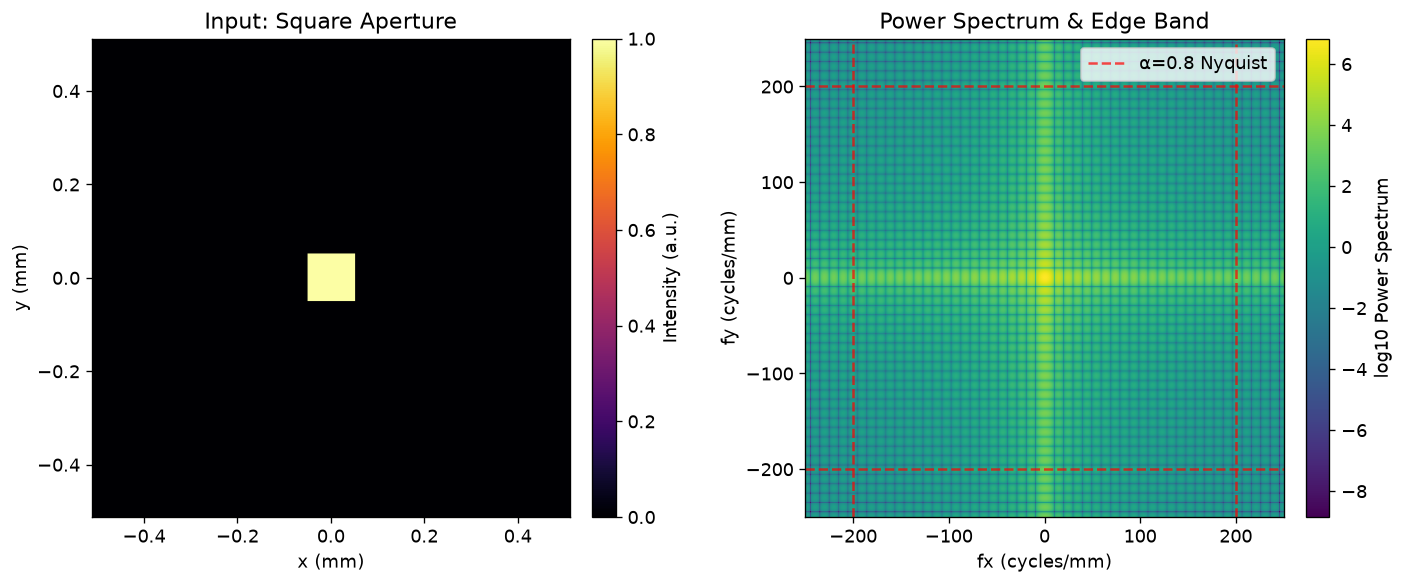

In [3]:
from propagation_sanity.plotting import plot_field_intensity, plot_spectrum_with_nyquist

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input field intensity
plot_field_intensity(contract.field, title="Input: Square Aperture", ax=axes[0])

# Input field power spectrum
plot_spectrum_with_nyquist(contract.field, alpha=0.8, ax=axes[1])

fig.tight_layout()
plt.show()

## 3. Propagate and visualise intensity evolution

We propagate to four distances: 1 mm, 10 mm, 100 mm, 150 mm.
As `z` increases, the diffraction pattern broadens and eventually reaches
the far field (Fraunhofer) regime.

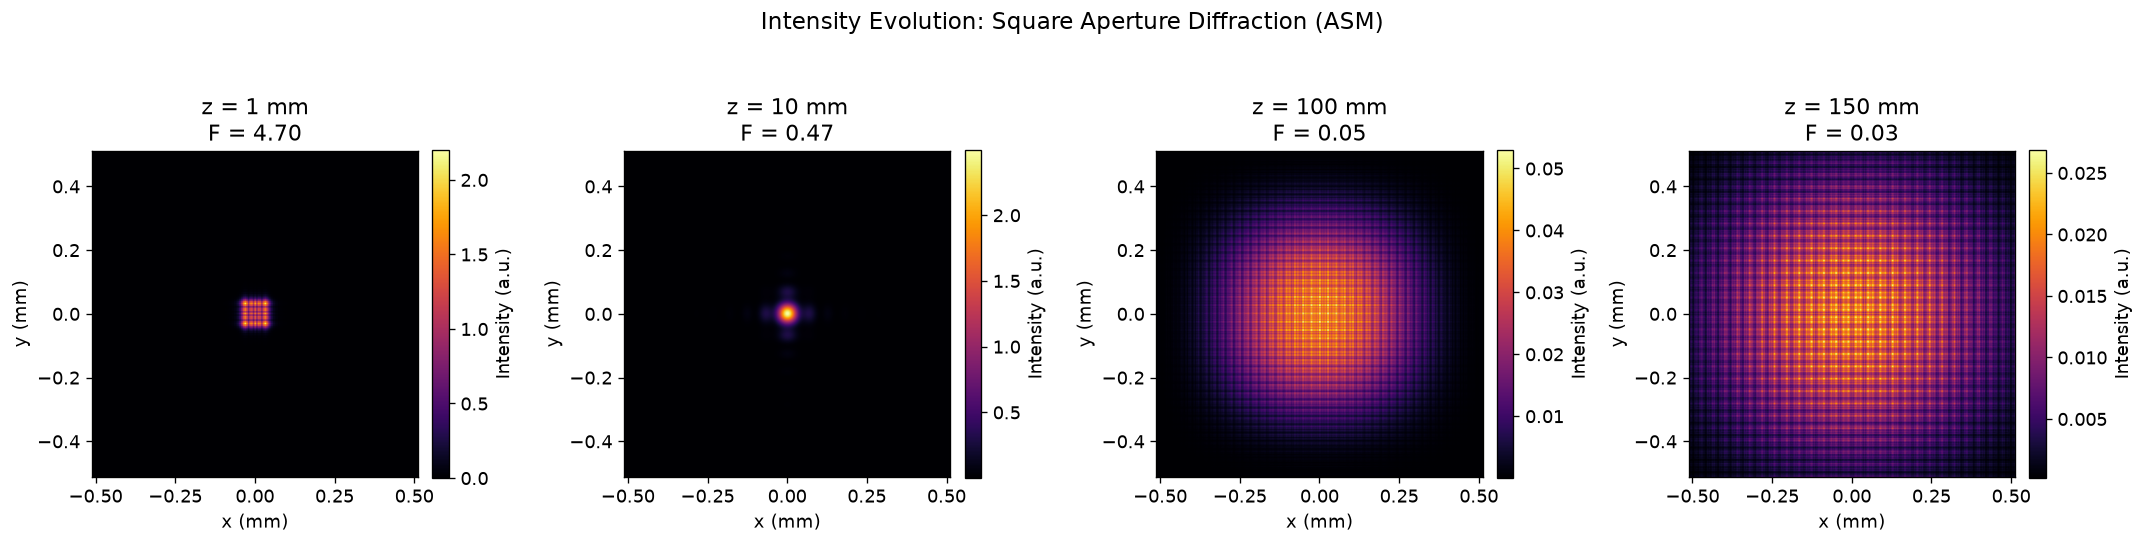

In [4]:
from propagation_sanity.adapters.waveprop_adapter import WavepropAdapter

adapter = WavepropAdapter()
z_list = [1e-3, 10e-3, 100e-3, 150e-3]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, z_val in zip(axes, z_list):
    c = build_square_aperture_contract(z=z_val)
    res = adapter.propagate(c.field, c.wave, z_val, c.propagation_config)

    # Fresnel number F = a² / (λ z)
    a = c.characteristic_size / 2.0
    F = a**2 / (c.wave.wavelength * z_val)

    plot_field_intensity(
        res.field,
        title=f"z = {z_val*1e3:.0f} mm\nF = {F:.2f}",
        ax=ax,
    )

fig.suptitle(
    "Intensity Evolution: Square Aperture Diffraction (ASM)", fontsize=14, y=1.02
)
fig.tight_layout()
plt.show()

## 4. Central-line intensity profile

Extract the 1D intensity along the horizontal centre of the output plane
to see the diffraction structure more clearly.

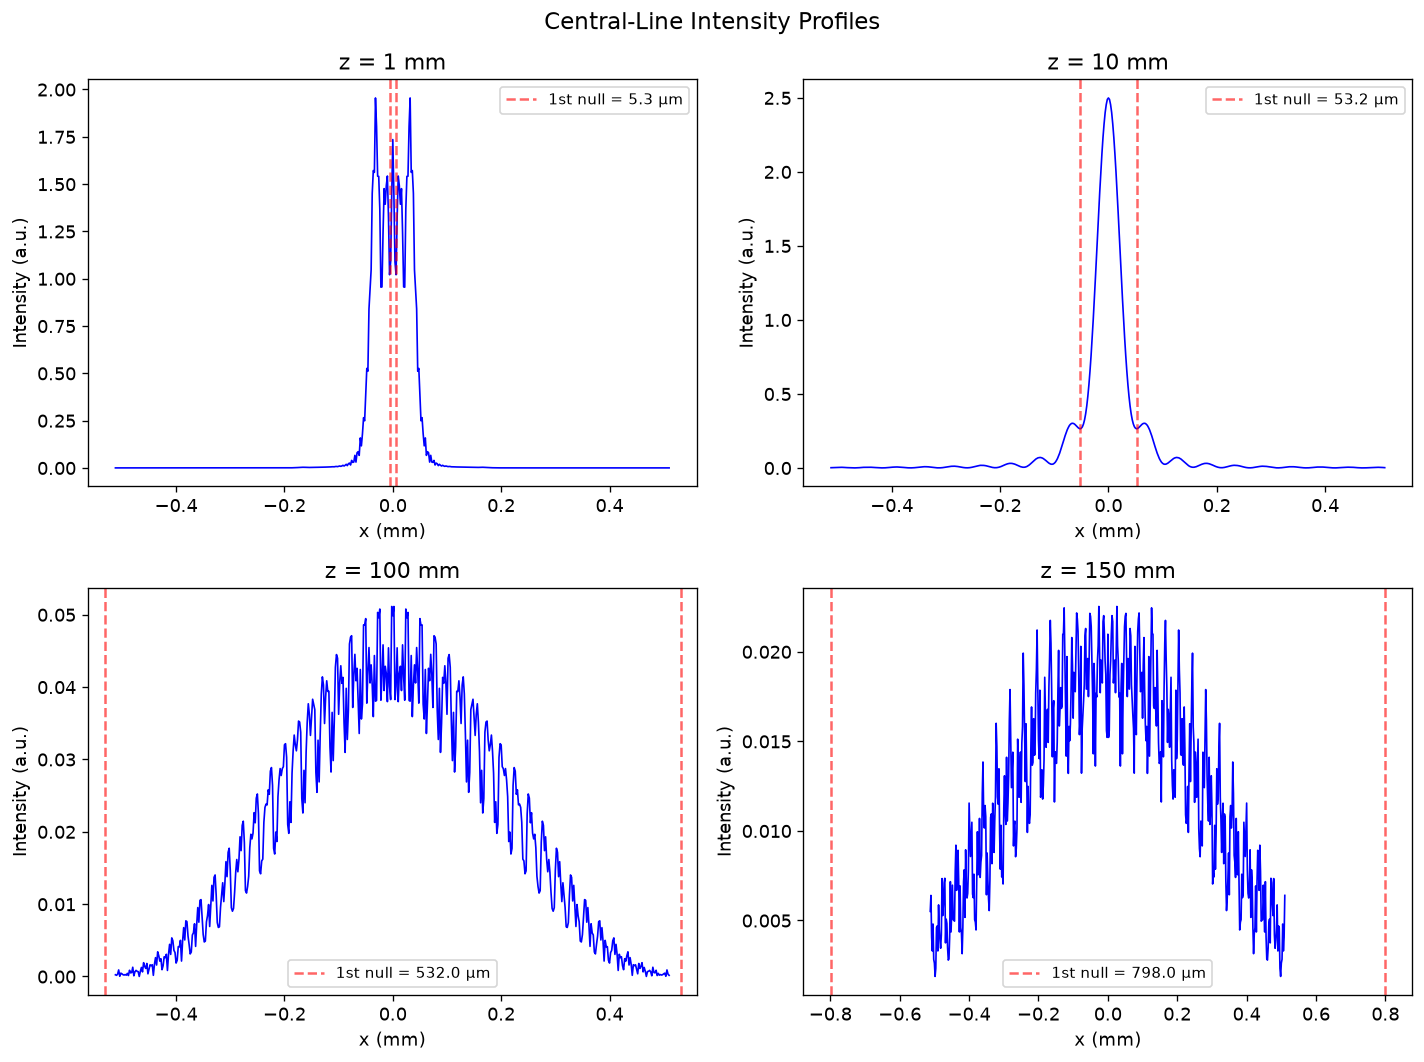

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, z_val in zip(axes.ravel(), z_list):
    c = build_square_aperture_contract(z=z_val)
    res = adapter.propagate(c.field, c.wave, z_val, c.propagation_config)

    intensity = res.field.intensity
    ny_mid = intensity.shape[0] // 2
    x_coords_mm = res.output_grid.x_coords() * 1e3

    ax.plot(x_coords_mm, intensity[ny_mid, :], "b-", lw=1)
    ax.set_title(f"z = {z_val*1e3:.0f} mm")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("Intensity (a.u.)")

    # Mark the analytic Fraunhofer first null: x₁ = λz / a
    a = c.characteristic_size
    x1 = c.wave.wavelength * z_val / a
    ax.axvline(
        x1 * 1e3, color="r", ls="--", alpha=0.6, label=f"1st null = {x1*1e6:.1f} μm"
    )
    ax.axvline(-x1 * 1e3, color="r", ls="--", alpha=0.6)
    ax.legend(fontsize=9)

fig.suptitle("Central-Line Intensity Profiles", fontsize=14)
fig.tight_layout()
plt.show()

## 5. ASM vs. Band-Limited ASM (BLAS) comparison

At short distances, ASM and BLAS agree perfectly.
At large z, the ASM transfer function oscillates faster than the sampling grid,
causing **chirp aliasing**.  BLAS (Matsushima & Shimobaba, Opt. Express 2009)
prevents this by zeroing aliased spectral components.

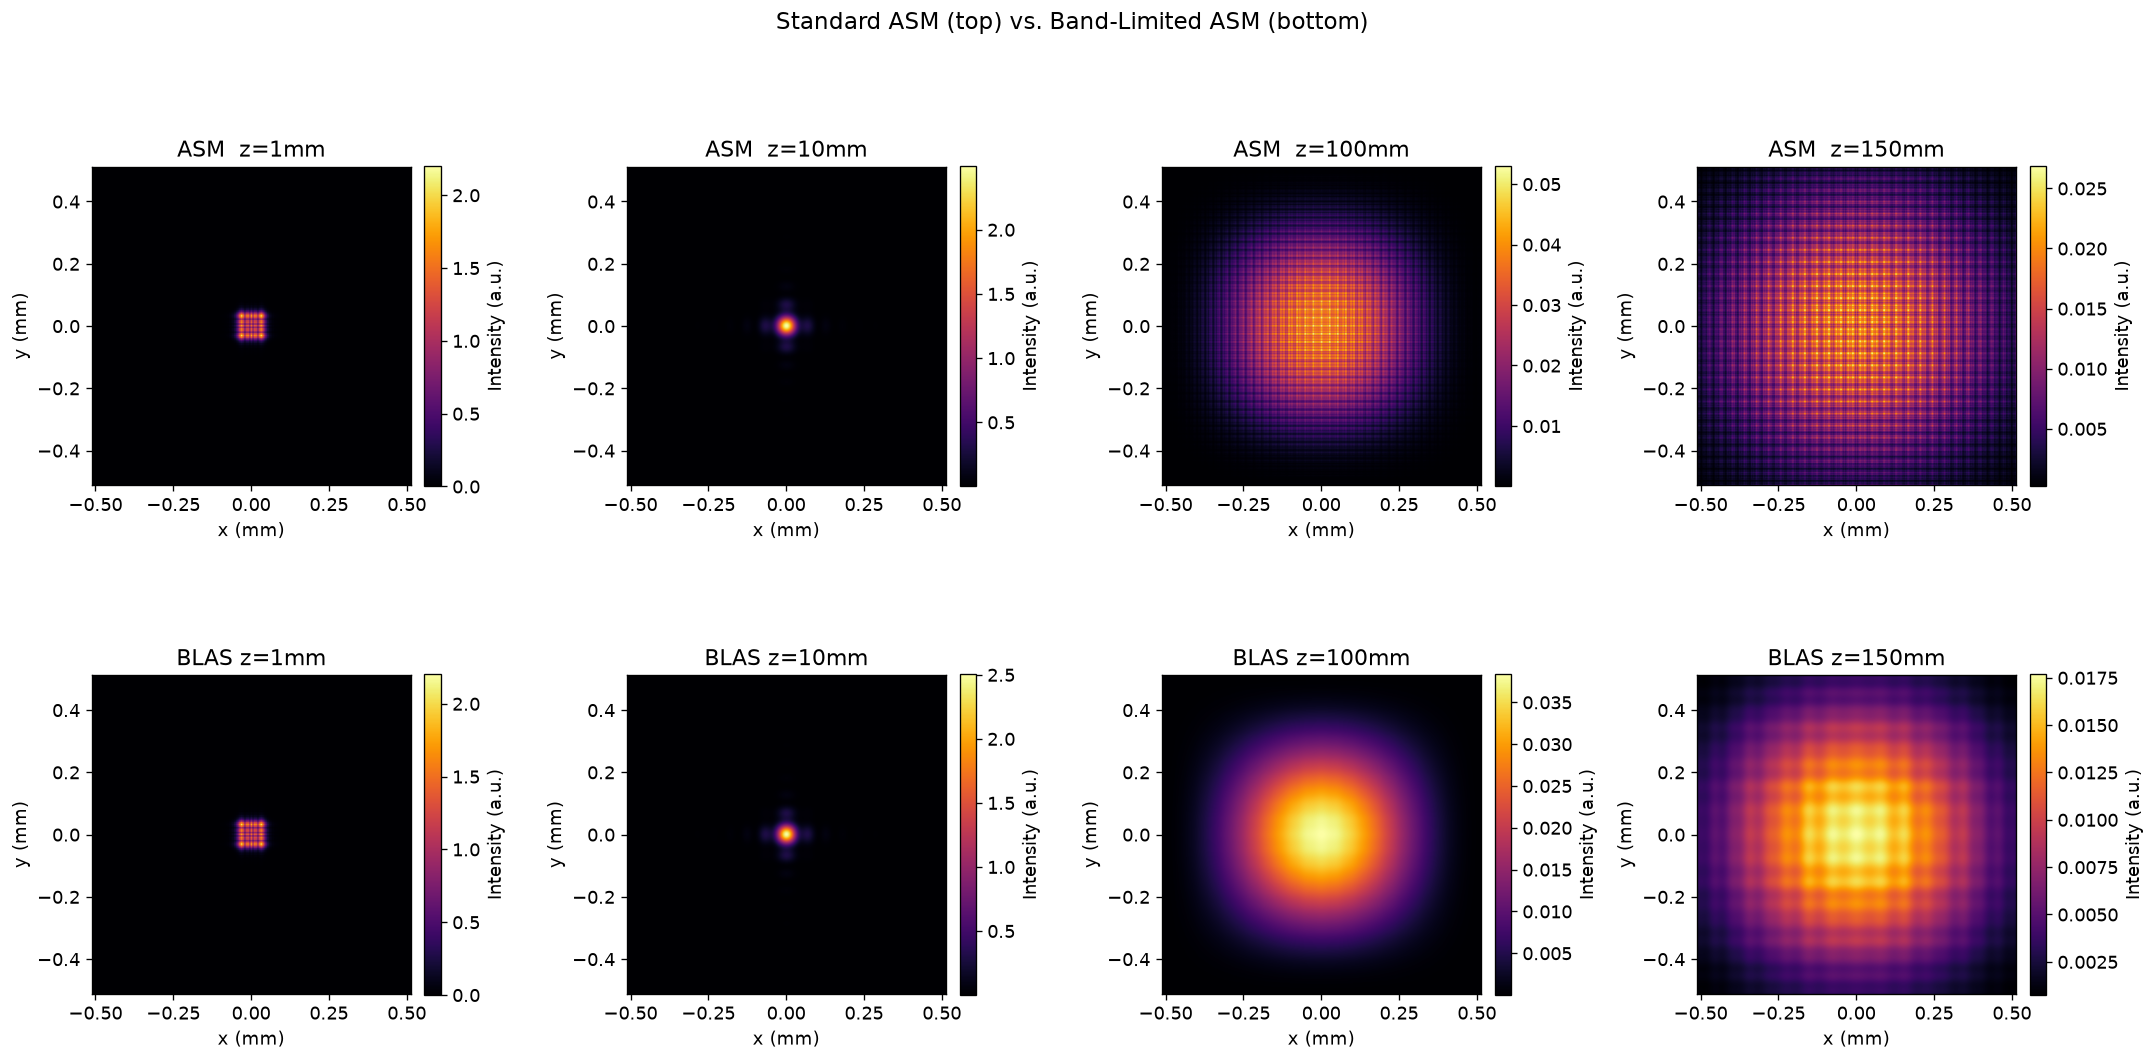


ASM vs BLAS intensity relative error (80% centre ROI):
---------------------------------------------
  z =      1 mm :  ε = 0.0000e+00   ✓
  z =     10 mm :  ε = 1.1580e-03   ✓
  z =    100 mm :  ε = 2.0078e-01   ⚠ aliasing
  z =    150 mm :  ε = 2.8198e-01   ⚠ aliasing


In [6]:
from propagation_sanity.core.roi import ROI
from propagation_sanity.core.metrics import intensity_relative_error

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
diffs = []

for col, z_val in enumerate(z_list):
    # Standard ASM
    c_std = build_square_aperture_contract(z=z_val, bandlimit=False)
    res_std = adapter.propagate(
        c_std.field, c_std.wave, z_val, c_std.propagation_config
    )

    # Band-limited ASM
    c_blas = build_square_aperture_contract(z=z_val, bandlimit=True)
    res_blas = adapter.propagate(
        c_blas.field, c_blas.wave, z_val, c_blas.propagation_config
    )

    # Plot ASM
    plot_field_intensity(
        res_std.field, title=f"ASM  z={z_val*1e3:.0f}mm", ax=axes[0, col]
    )
    # Plot BLAS
    plot_field_intensity(
        res_blas.field, title=f"BLAS z={z_val*1e3:.0f}mm", ax=axes[1, col]
    )

    # Relative difference
    roi = ROI.from_grid_center(c_std.grid, fraction=0.8)
    diff = intensity_relative_error(res_std.field, res_blas.field, roi=roi)
    diffs.append((z_val, diff))

fig.suptitle("Standard ASM (top) vs. Band-Limited ASM (bottom)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Print differences
print("\nASM vs BLAS intensity relative error (80% centre ROI):")
print("-" * 45)
for z_val, diff in diffs:
    flag = "✓" if diff < 0.05 else "⚠ aliasing"
    print(f"  z = {z_val*1e3:6.0f} mm :  ε = {diff:.4e}   {flag}")

## 6. Full validation report

The `validate()` function runs all applicable checks:
derived grid quantities, spectral/boundary diagnostics,
Matsushima admissible-band criterion, Fresnel number, etc.

In [7]:
from propagation_sanity.validate import validate

# Build contract for z = 100 mm
contract_100 = build_square_aperture_contract(z=100e-3)
report = validate(contract_100, run_convergence=False)

print(report.summary())

NUMERICAL PROPAGATION VALIDATION

Simulation
----------------------------------------
  nx                    512
  ny                    512
  dx                    2.0000e-06
  dy                    2.0000e-06
  Lx                    0.001024
  Ly                    0.001024
  wavelength            5.3200e-07
  z                     0.1
  method                asm

Derived
----------------------------------------
  nx                    512
  ny                    512
  dx                    2.0000e-06
  dy                    2.0000e-06
  Lx                    0.001024
  Ly                    0.001024
  dfx                   976.562500
  dfy                   976.562500
  nyquist_x             2.5000e+05
  nyquist_y             2.5000e+05

Diagnostics
----------------------------------------
  Spectral edge energy  0.004178
  Effective bandwidth   {'radial': {'95.0%': 37429.234173314064, '99.0%': 142591.5019409686, '99.9%': 239259.8054763933}, 'x': {'95.0%': 18554.6875, '99.0%': 8984

### Inspect individual report items

In [8]:
from propagation_sanity.core.report import AssessmentType

# Show diagnostic items
for item in report.get_items_by_type(AssessmentType.DIAGNOSTIC):
    print(f"[{item.status.value:10s}] {item.title}")
    if item.interpretation:
        print(f"            → {item.interpretation}")
    print()

# Show formal criteria
print("=" * 50)
print("Formal Criteria:")
for item in report.get_items_by_type(AssessmentType.FORMAL_CRITERION):
    symbol = "✓" if item.status.value == "pass" else "✗"
    print(f"  {symbol} {item.title}: {item.status.value.upper()}")
    if item.interpretation:
        print(f"    {item.interpretation}")

[info      ] Spectral edge energy
            → Low spectral energy near Nyquist edge.

[info      ] Effective bandwidth
            → Effective spectral support at various coverage levels.

[info      ] Boundary energy
            → Field energy is well-contained within the computation domain.

[info      ] Paraxial FOV
            → Frequencies above f_safe may diffract beyond the window. f_safe/f_Nyquist = (0.04, 0.04). This is a paraxial estimate and does not replace convergence.

[info      ] ASM phase step
            → Max ASM phase step is 26.4π — the transfer function varies rapidly between adjacent frequency samples. Standard ASM may produce aliased results.

[info      ] Fresnel phase error
            → Maximum Fresnel-approximation phase error is 47.58 rad (15.14π). Fresnel propagation may be inaccurate; consider using ASM.

[info      ] Fresnel number
            → N_F = 0.1880 — Transition to Fraunhofer.

[info      ] Feature pixels
            → Characteristic feature s

## 7. Fresnel number and diffraction regime

The Fresnel number $F = \frac{a^2}{\lambda z}$ classifies the regime:
- $F \gg 1$: near-field (geometric shadow)
- $F \sim 1$: Fresnel diffraction  
- $F \ll 1$: Fraunhofer (far-field)

In [9]:
from propagation_sanity.benchmarks.square_aperture import run_square_aperture_suite

suite = run_square_aperture_suite(z_list=z_list)

print(
    f"{'z (mm)':>10}  {'Fresnel #':>10}  {'1st null (μm)':>14}  {'ASM-BLAS diff':>14}"
)
print("-" * 55)
for z_val in z_list:
    key = f"z_{int(z_val*1e3)}mm"
    r = suite[key]
    print(
        f"{z_val*1e3:10.0f}  {r['fresnel_number']:10.3f}"
        f"  {r['fraunhofer_first_null']*1e6:14.1f}"
        f"  {r['blas_intensity_relative_diff']:14.4e}"
    )

    z (mm)   Fresnel #   1st null (μm)   ASM-BLAS diff
-------------------------------------------------------
         1       4.699             5.3      0.0000e+00
        10       0.470            53.2      1.1580e-03
       100       0.047           532.0      2.0078e-01
       150       0.031           798.0      2.8198e-01


## Key takeaways

1. **Chirp aliasing is real**: At z = 150 mm (Fresnel number ≈ 0.2),
   standard ASM produces visible artefacts compared to BLAS.
2. **Matsushima criterion detects it**: The formal criterion returns FAIL
   for z = 150 mm without band limiting, correctly flagging the
   under-resolved transfer function phase.
3. **Diagnostics ≠ proof**: Spectral edge energy and boundary diagnostics
   are risk indicators, not universal PASS/FAIL criteria.